# Customer Conversion with Clickstream Data

This notebook demonstrates how to analyze e-commerce clickstream data to predict customer conversions, estimate purchase amounts, and segment customers for targeted marketing campaigns.

**Key Learning Objectives:**
1. Generate and explore realistic e-commerce data
2. Build a classification model to predict customer conversions
3. Create a regression model to predict purchase amounts
4. Segment customers using clustering techniques
5. Develop marketing recommendations for different customer segments

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import pickle
from datetime import datetime, timedelta

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 1. Generate Sample E-commerce Data

First, we'll create a realistic dataset that simulates user behavior on an e-commerce website. This includes features like:
- Number of page views
- Time spent on site
- Product page views
- Add-to-cart actions
- Cart abandonment
- Device type (desktop, mobile, tablet)
- Referral source (where the user came from)

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of users/sessions
n_users = 1000

# Create user IDs and session data
user_ids = [f"user_{i}" for i in range(n_users)]
session_ids = [f"session_{i}" for i in range(n_users)]

# Session timestamps - spread over last 30 days
now = datetime.now()
session_starts = [now - timedelta(
    days=np.random.randint(1, 30),
    hours=np.random.randint(0, 24),
    minutes=np.random.randint(0, 60)
) for _ in range(n_users)]

# Generate session behavior features
page_views = np.random.randint(1, 50, n_users)
time_spent = np.random.uniform(10, 1800, n_users)  # 10 sec to 30 min
product_page_views = np.random.randint(0, 20, n_users)
add_to_cart_actions = np.random.randint(0, 5, n_users)
cart_abandonment = np.random.choice([0, 1], n_users, p=[0.7, 0.3])
search_count = np.random.randint(0, 10, n_users)

# Device and referral source
devices = np.random.choice(['desktop', 'mobile', 'tablet'], n_users, p=[0.5, 0.4, 0.1])
referral_sources = np.random.choice(
    ['direct', 'organic_search', 'social_media', 'email', 'paid_ad'],
    n_users,
    p=[0.2, 0.3, 0.2, 0.15, 0.15]
)

# User demographics (some will be missing to simulate real data)
age_groups = np.random.choice(
    [np.nan, '18-24', '25-34', '35-44', '45-54', '55+'],
    n_users,
    p=[0.3, 0.1, 0.2, 0.2, 0.1, 0.1]
)

### Generate Conversion Outcomes

Now we'll create a realistic model for whether users convert (make a purchase) based on their behavior. 

**Key Concept:** We model conversion probability as influenced by multiple factors:
- Time spent on site (longer = higher probability)
- Product views (more views = higher probability)
- Cart actions (more add-to-cart = higher probability)
- Device type (desktop converts better than mobile)
- Referral source (email and paid ads convert better)

In [3]:
# Calculate purchase probability based on user behavior
purchase_prob = (
    0.01 +  # base rate
    0.02 * (time_spent / 1800) +  # time effect
    0.1 * (product_page_views / 20) +  # product views effect
    0.1 * (add_to_cart_actions / 5) -  # cart actions effect
    0.2 * cart_abandonment +  # abandonment effect
    (devices == 'desktop') * 0.05 +  # device effect
    (referral_sources == 'email') * 0.08 +  # email effect
    (referral_sources == 'paid_ad') * 0.07  # paid ad effect
)

# Clip probabilities to [0, 0.8] range
purchase_prob = np.clip(purchase_prob, 0, 0.8)

# Generate purchase outcomes using binomial distribution
converted = np.random.binomial(n=1, p=purchase_prob)

# Calculate purchase amount for converted users
purchase_amount = np.zeros(n_users)
for i in range(n_users):
    if converted[i] == 1:
        # Purchase amount influenced by product views and add to cart
        base_amount = 50 + 10 * product_page_views[i] + 15 * add_to_cart_actions[i]
        # Add some random variation
        purchase_amount[i] = base_amount + np.random.normal(0, 20)

### Create DataFrame and Engineer Features

Now we'll combine all our data into a DataFrame and create additional features that might help with prediction:

**Feature Engineering Concepts:**
- **session_day/hour**: Day of week and hour of day when session occurred
- **bounce**: Whether the user only viewed one page (a "bounce" in web analytics)
- **avg_time_per_page**: Average time spent per page (engagement quality)
- **cart_view_ratio**: Ratio of add-to-cart actions to product views (conversion efficiency)

In [4]:
# Create DataFrame
clickstream_data = pd.DataFrame({
    'user_id': user_ids,
    'session_id': session_ids,
    'session_timestamp': session_starts,
    'page_views': page_views,
    'time_spent_sec': time_spent,
    'product_page_views': product_page_views,
    'add_to_cart_actions': add_to_cart_actions,
    'cart_abandonment': cart_abandonment,
    'search_count': search_count,
    'device': devices,
    'referral_source': referral_sources,
    'age_group': age_groups,
    'converted': converted,
    'purchase_amount': purchase_amount
})

# Feature Engineering
clickstream_data['session_day'] = clickstream_data['session_timestamp'].dt.day_name()
clickstream_data['session_hour'] = clickstream_data['session_timestamp'].dt.hour
clickstream_data['bounce'] = (clickstream_data['page_views'] == 1).astype(int)
clickstream_data['avg_time_per_page'] = clickstream_data['time_spent_sec'] / clickstream_data['page_views']
clickstream_data['cart_view_ratio'] = np.where(
    clickstream_data['product_page_views'] > 0,
    clickstream_data['add_to_cart_actions'] / clickstream_data['product_page_views'],
    0
)

# Display the first few rows of the dataset
clickstream_data.head()

,user_id,session_id,session_timestamp,page_views,time_spent_sec,product_page_views,add_to_cart_actions,cart_abandonment,search_count,device,referral_source,age_group,converted,purchase_amount,session_day,session_hour,bounce,avg_time_per_page,cart_view_ratio
0,user_0,session_0,2025-04-18 12:11:54.804594,26,187.750943,15,3,1,0,mobile,direct,18-24,0,0.0,Friday,12,0,7.221190,0.200000
1,user_1,session_1,2025-04-10 21:32:54.804594,4,383.866687,2,2,1,1,desktop,organic_search,25-34,0,0.0,Thursday,21,0,95.966672,1.000000
2,user_2,session_2,2025-03-27 11:01:54.804594,34,1666.890821,5,2,1,6,tablet,organic_search,45-54,0,0.0,Thursday,11,0,49.026201,0.400000
3,user_3,session_3,2025-03-30 13:17:54.804594,48,751.328902,13,4,0,3,desktop,organic_search,25-34,0,0.0,Sunday,13,0,15.652685,0.307692
4,user_4,session_4,2025-04-14 21:16:54.804594,18,717.827340,17,4,0,9,mobile,direct,nan,0,0.0,Monday,21,0,39.879297,0.235294


## 2. Exploratory Data Analysis (EDA)

Let's explore our clickstream data to understand customer behavior patterns and what drives conversions.

In [5]:
# Basic dataset information
print("Dataset Shape:", clickstream_data.shape)
print("\nData Types:")
print(clickstream_data.dtypes)
print("\nMissing Values:")
print(clickstream_data.isnull().sum())
print("\nConversion Rate:", f"{clickstream_data['converted'].mean():.2%}")
print("Avg Purchase Amount (converters only):", f"${clickstream_data[clickstream_data['converted']==1]['purchase_amount'].mean():.2f}")

Dataset Shape: (1000, 19)

Data Types:
user_id                        object
session_id                     object
session_timestamp      datetime64[ns]
page_views                      int32
time_spent_sec                float64
product_page_views              int32
add_to_cart_actions             int32
cart_abandonment                int32
search_count                    int32
device                         object
referral_source                object
age_group                      object
converted                       int32
purchase_amount               float64
session_day                    object
session_hour                    int32
bounce                          int32
avg_time_per_page             float64
cart_view_ratio               float64
dtype: object

Missing Values:
user_id                0
session_id             0
session_timestamp      0
page_views             0
time_spent_sec         0
product_page_views     0
add_to_cart_actions    0
cart_abandonment       0
search_c

In [6]:
# Explore conversion rate by various factors
# 1. Conversion by device
device_conv = clickstream_data.groupby('device')['converted'].mean().sort_values(ascending=False)
print("\nConversion Rate by Device:")
print(device_conv)

# 2. Conversion by referral source
referral_conv = clickstream_data.groupby('referral_source')['converted'].mean().sort_values(ascending=False)
print("\nConversion Rate by Referral Source:")
print(referral_conv)

# 3. Average purchase amount by referral source
referral_purchase = clickstream_data[clickstream_data['converted'] == 1].groupby('referral_source')['purchase_amount'].mean().sort_values(ascending=False)
print("\nAverage Purchase Amount by Referral Source:")
print(referral_purchase)


Conversion Rate by Device:
device
desktop    0.123950
mobile     0.099537
tablet     0.054348
Name: converted, dtype: float64

Conversion Rate by Referral Source:
referral_source
email             0.170732
paid_ad           0.143836
organic_search    0.087379
social_media      0.085714
direct            0.077670
Name: converted, dtype: float64

Average Purchase Amount by Referral Source:
referral_source
social_media      215.100752
direct            204.434377
email             184.327183
organic_search    179.787951
paid_ad           177.674909
Name: purchase_amount, dtype: float64


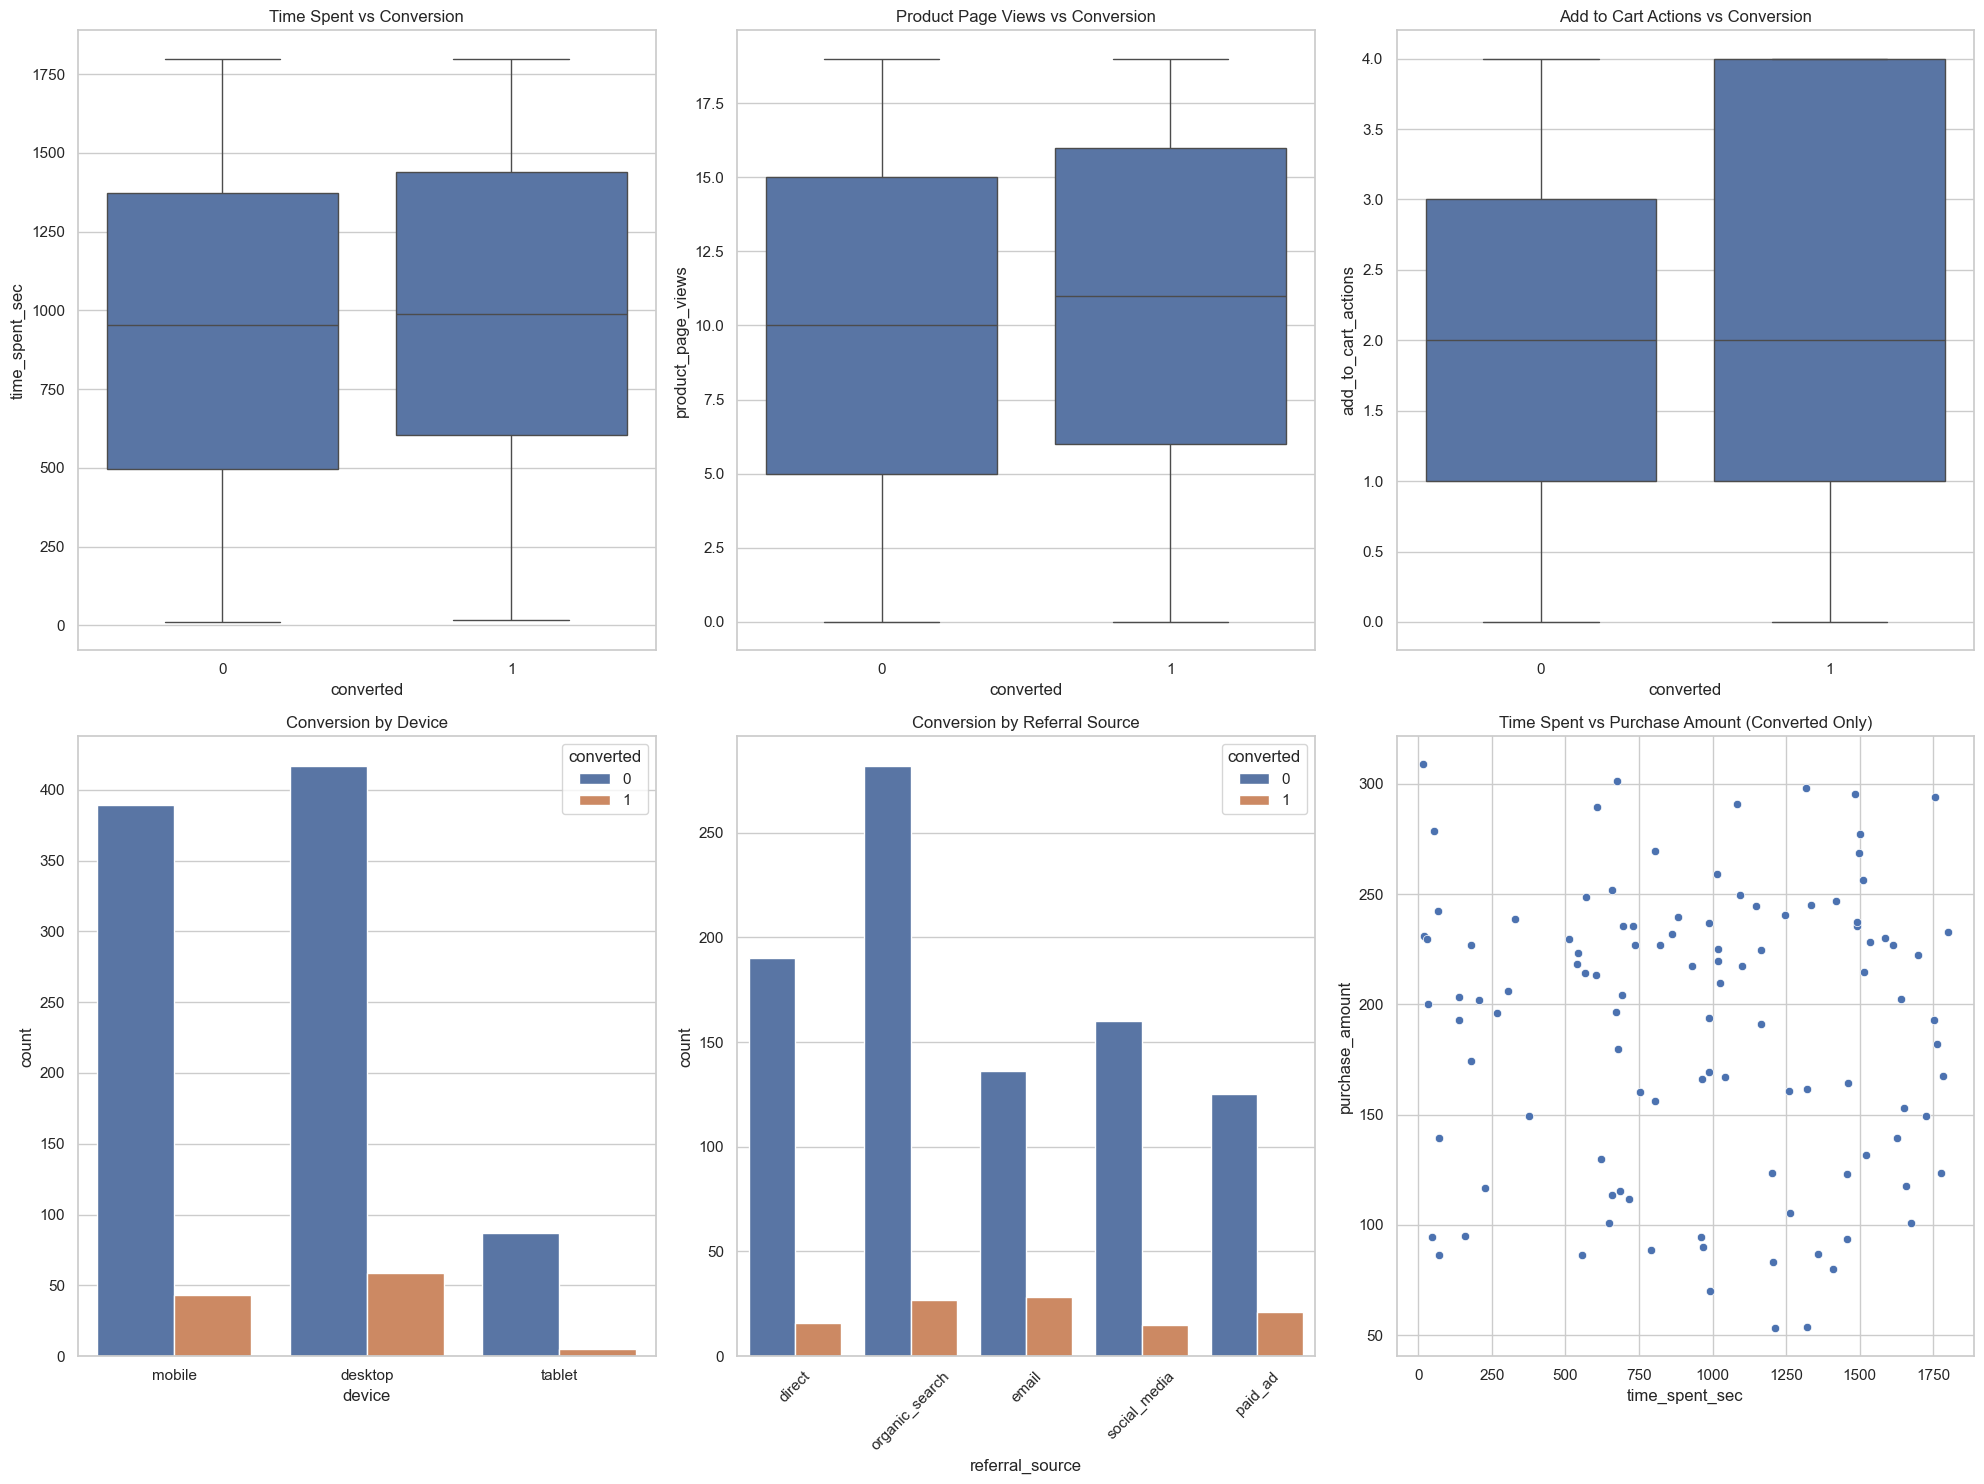

In [7]:
# Visualize key relationships
plt.figure(figsize=(20, 15))

# 1. Time spent vs conversion
plt.subplot(2, 3, 1)
sns.boxplot(x='converted', y='time_spent_sec', data=clickstream_data)
plt.title('Time Spent vs Conversion')

# 2. Product views vs conversion
plt.subplot(2, 3, 2)
sns.boxplot(x='converted', y='product_page_views', data=clickstream_data)
plt.title('Product Page Views vs Conversion')

# 3. Add to cart actions vs conversion
plt.subplot(2, 3, 3)
sns.boxplot(x='converted', y='add_to_cart_actions', data=clickstream_data)
plt.title('Add to Cart Actions vs Conversion')

# 4. Conversion by device
plt.subplot(2, 3, 4)
sns.countplot(x='device', hue='converted', data=clickstream_data)
plt.title('Conversion by Device')

# 5. Conversion by referral source
plt.subplot(2, 3, 5)
sns.countplot(x='referral_source', hue='converted', data=clickstream_data)
plt.title('Conversion by Referral Source')
plt.xticks(rotation=45)

# 6. Time spent vs purchase amount
plt.subplot(2, 3, 6)
sns.scatterplot(x='time_spent_sec', y='purchase_amount', data=clickstream_data[clickstream_data['converted'] == 1])
plt.title('Time Spent vs Purchase Amount (Converted Only)')

plt.tight_layout()
plt.show()

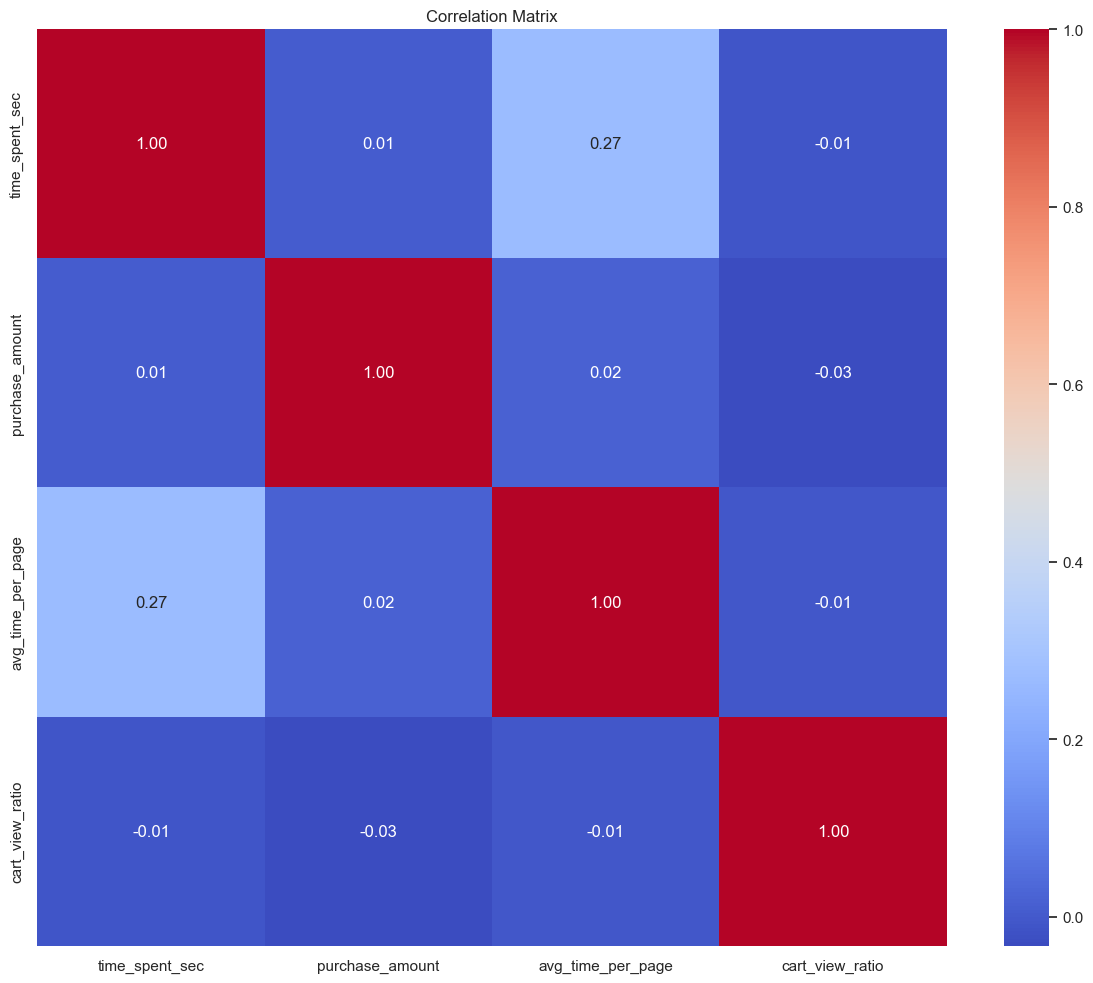

In [8]:
# Correlation analysis of numeric features
plt.figure(figsize=(12, 10))
corr = clickstream_data.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Prepare Data for Modeling

Before building our models, we need to prepare the data by:
- Handling missing values
- Encoding categorical variables
- Splitting data into training and testing sets
- Transforming cyclical features like hour of day

In [9]:
def prepare_data_for_modeling(df):
    """Prepare clickstream data for machine learning models"""
    # Create a copy to avoid modifying the original
    modeling_df = df.copy()
    
    # Handle missing values in age_group
    modeling_df['age_group'].fillna('unknown', inplace=True)
    
    # Select features
    features = [
        'page_views', 'time_spent_sec', 'product_page_views', 'add_to_cart_actions',
        'cart_abandonment', 'search_count', 'bounce', 'avg_time_per_page',
        'cart_view_ratio', 'session_hour', 'device', 'referral_source', 'age_group'
    ]
    
    X = modeling_df[features].copy()
    
    # Define the targets based on the tasks
    y_classification = modeling_df['converted']  # For conversion prediction
    y_regression = modeling_df[modeling_df['converted'] == 1]['purchase_amount']  # For purchase amount prediction
    
    # Encode categorical variables
    categorical_features = ['device', 'referral_source', 'age_group']
    label_encoders = {}
    
    for feature in categorical_features:
        le = LabelEncoder()
        X[feature] = le.fit_transform(X[feature])
        label_encoders[feature] = le
    
    # Transform hour (cyclical feature) to sine and cosine components
    # This preserves the cyclical nature (hour 23 is close to hour 0)
    X['hour_sin'] = np.sin(2 * np.pi * X['session_hour'] / 24)
    X['hour_cos'] = np.cos(2 * np.pi * X['session_hour'] / 24)
    X.drop('session_hour', axis=1, inplace=True)
    
    return X, y_classification, y_regression, label_encoders

# Prepare data
X, y_classification, y_regression, label_encoders = prepare_data_for_modeling(clickstream_data)

# Split data for classification task
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

# Display preprocessing results
print("Processed feature matrix shape:", X.shape)
print("Number of features after preprocessing:", X.shape[1])
print("\nFeatures:")
print(X.columns.tolist())

Processed feature matrix shape: (1000, 14)
Number of features after preprocessing: 14

Features:
['page_views', 'time_spent_sec', 'product_page_views', 'add_to_cart_actions', 'cart_abandonment', 'search_count', 'bounce', 'avg_time_per_page', 'cart_view_ratio', 'device', 'referral_source', 'age_group', 'hour_sin', 'hour_cos']


C:\Users\karth\AppData\Local\Temp\ipykernel_41720\1500610030.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  modeling_df['age_group'].fillna('unknown', inplace=True)


## 4. Conversion Prediction Model (Classification)

Now we'll build a model to predict whether a user will convert (make a purchase) based on their behavior.

**Key Steps:**
1. Create a pipeline with scaling and a Random Forest classifier
2. Train the model on our training data
3. Evaluate performance on test data
4. Analyze feature importance to understand what drives conversions

In [10]:
# Create a pipeline with preprocessing and model
clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scale all features to same range
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train the model
clf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = clf_pipeline.predict(X_test)
y_pred_prob = clf_pipeline.predict_proba(X_test)[:, 1]  # Probability of conversion

# Evaluate performance
print("Classification Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Classification Model Performance:
Accuracy: 0.8900

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       178
           1       0.00      0.00      0.00        22

    accuracy                           0.89       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.79      0.89      0.84       200


Confusion Matrix:
[[178   0]
 [ 22   0]]


C:\Users\karth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\karth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\karth\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

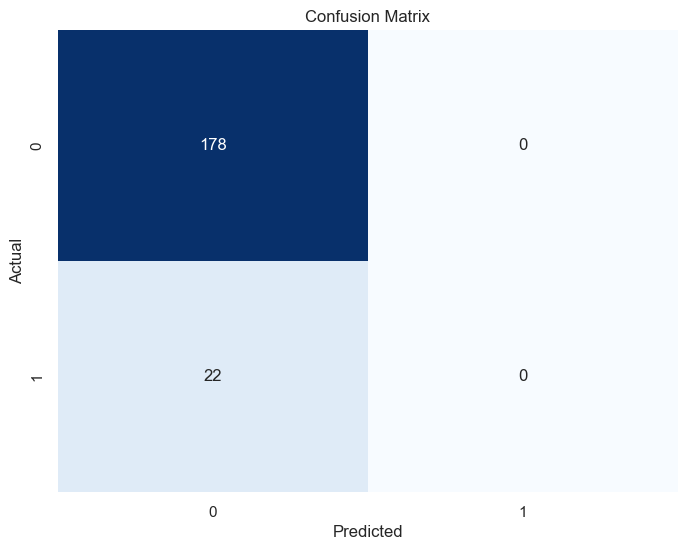

In [11]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Top 10 Features for Conversion Prediction:
               Feature  Importance
1       time_spent_sec    0.142449
7    avg_time_per_page    0.136199
0           page_views    0.108000
2   product_page_views    0.095369
12            hour_sin    0.078667
8      cart_view_ratio    0.078659
13            hour_cos    0.068960
5         search_count    0.067864
11           age_group    0.057508
10     referral_source    0.052437


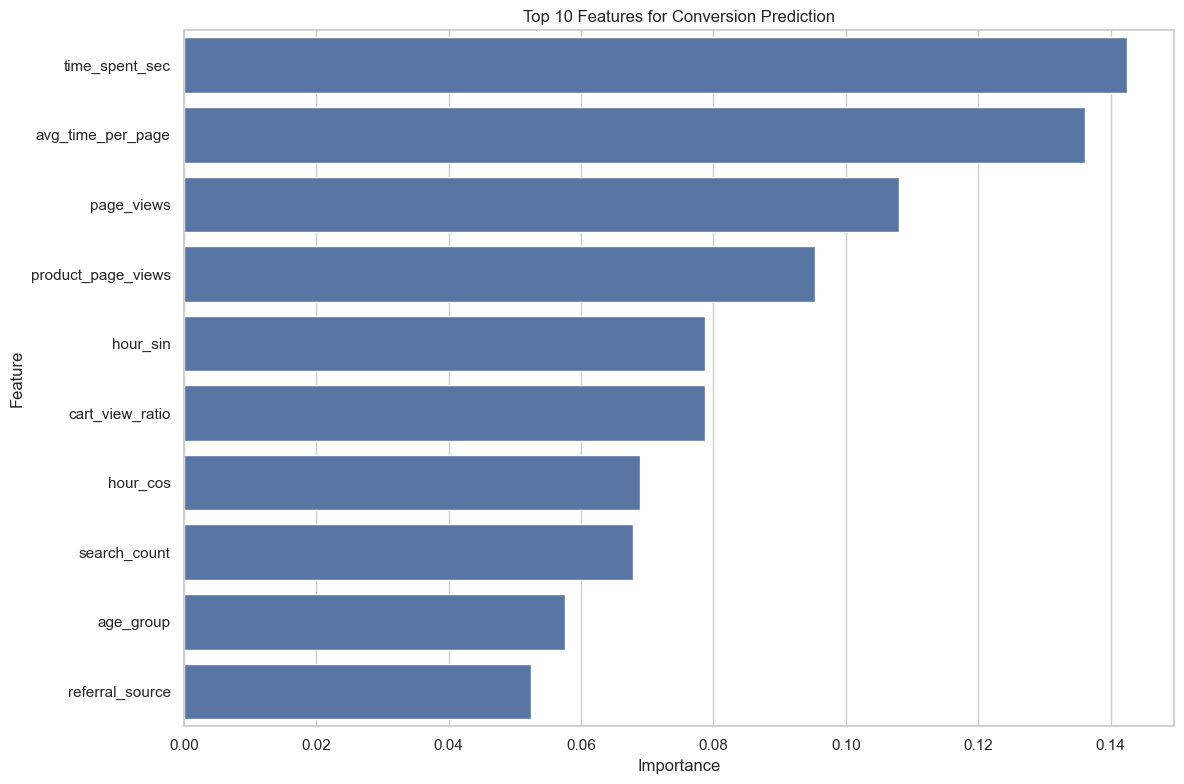

In [12]:
# Analyze feature importance
feature_importances = clf_pipeline.named_steps['classifier'].feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Features for Conversion Prediction:")
print(feature_importance_df.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(10)
sns.barplot(x='Importance', y='Feature', data=top_features)
plt.title('Top 10 Features for Conversion Prediction')
plt.tight_layout()
plt.show()

## 5. Purchase Amount Prediction Model (Regression)

For users who convert, we want to predict how much they'll spend. This is a regression task.

**Key Concept:** We're building a two-stage model:
1. First model predicts if a user will convert (classification)
2. Second model predicts purchase amount for converters (regression)

In [13]:
# Filter only converted users for regression task
converted_df = clickstream_data[clickstream_data['converted'] == 1].copy()

# Feature selection for regression
features = [
    'page_views', 'time_spent_sec', 'product_page_views', 'add_to_cart_actions',
    'search_count', 'avg_time_per_page', 'device', 'referral_source'
]

X_reg = converted_df[features].copy()
y_reg = converted_df['purchase_amount']

# Encode categorical variables
categorical_features = ['device', 'referral_source']
for feature in categorical_features:
    le = LabelEncoder()
    X_reg[feature] = le.fit_transform(X_reg[feature])

# Split data for regression task
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Create and train the regression model
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

reg_pipeline.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = reg_pipeline.predict(X_test_reg)

# Evaluate regression model
mse = np.mean((y_test_reg - y_pred_reg) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_test_reg - y_pred_reg))

print("Regression Model Performance:")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

Regression Model Performance:
MSE: 981.65
RMSE: 31.33
MAE: 26.43


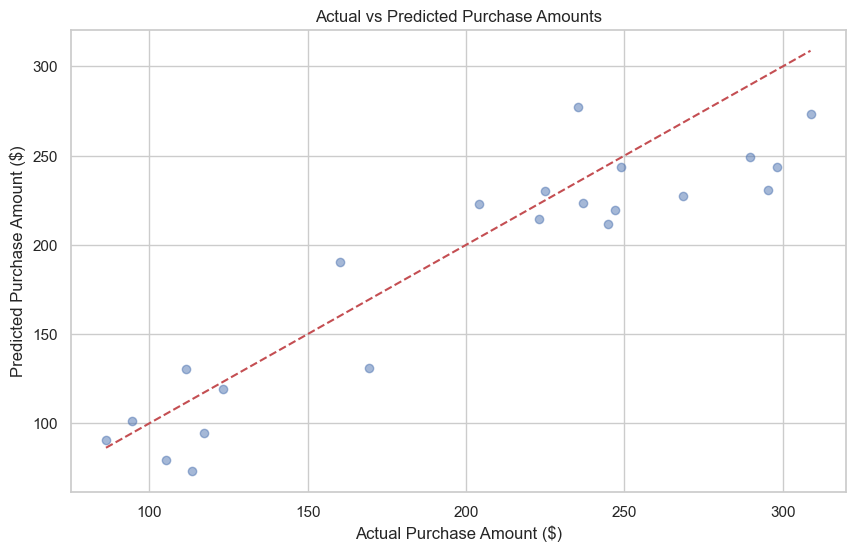

In [14]:
# Plot actual vs predicted purchase amounts
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('Actual vs Predicted Purchase Amounts')
plt.xlabel('Actual Purchase Amount ($)')
plt.ylabel('Predicted Purchase Amount ($)')
plt.show()

## 6. Customer Segmentation with K-means Clustering

Now we'll use unsupervised learning (clustering) to segment customers based on their behavior patterns. This will help us develop targeted marketing strategies.

**Key Concepts:**
- Use K-means clustering to group similar users
- Find optimal number of clusters using the Elbow method
- Analyze each cluster to create meaningful customer personas

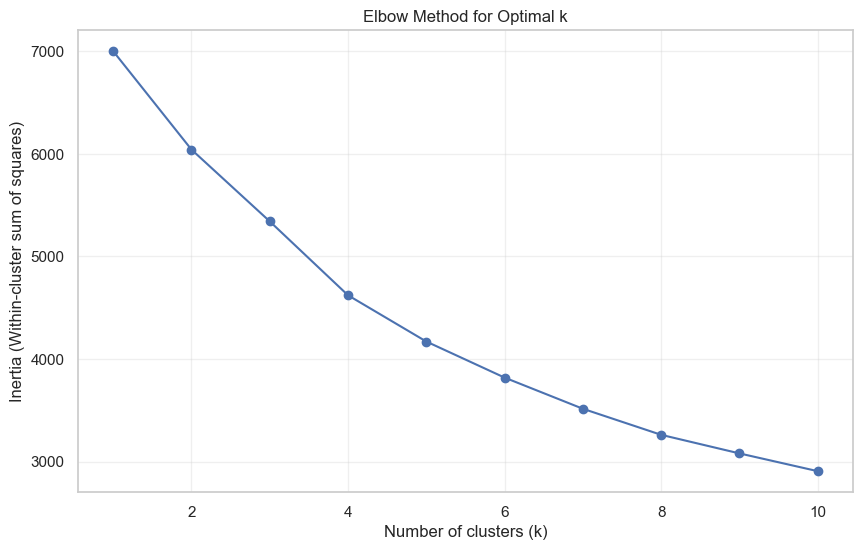

Using 4 clusters based on the Elbow method.


In [15]:
# Select features for clustering
cluster_features = [
    'page_views', 'time_spent_sec', 'product_page_views', 'add_to_cart_actions',
    'search_count', 'avg_time_per_page', 'cart_view_ratio'
]

# Create a DataFrame for clustering
cluster_df = clickstream_data[cluster_features].copy()

# Scale the data for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

# Find optimal number of clusters using the Elbow method
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot Elbow method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'o-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True, alpha=0.3)
plt.show()

# Based on the elbow method, choose optimal number of clusters
n_clusters = 4  # Typically, this would be where the 'elbow' occurs
print(f"Using {n_clusters} clusters based on the Elbow method.")

In [16]:
# Perform K-means clustering with chosen number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to original data
clickstream_with_clusters = clickstream_data.copy()
clickstream_with_clusters['cluster'] = clusters

# Analyze cluster characteristics
cluster_analysis = clickstream_with_clusters.groupby('cluster').agg({
    'page_views': 'mean',
    'time_spent_sec': 'mean',
    'product_page_views': 'mean',
    'add_to_cart_actions': 'mean',
    'search_count': 'mean',
    'avg_time_per_page': 'mean',
    'cart_view_ratio': 'mean',
    'converted': 'mean',
    'purchase_amount': lambda x: x[x > 0].mean() if sum(x > 0) > 0 else 0,
    'user_id': 'count'
}).rename(columns={'user_id': 'count'})

# Format cluster analysis for better readability
for col in cluster_analysis.columns:
    if col in ['page_views', 'product_page_views', 'add_to_cart_actions', 'search_count', 'count']:
        cluster_analysis[col] = cluster_analysis[col].round(0).astype(int)
    elif col in ['time_spent_sec', 'avg_time_per_page', 'purchase_amount']:
        cluster_analysis[col] = cluster_analysis[col].round(2)
    elif col == 'converted':
        cluster_analysis[col] = (cluster_analysis[col] * 100).round(2).astype(str) + '%'

print("\nCluster Analysis:")
print(cluster_analysis)


Cluster Analysis:
         page_views  time_spent_sec  product_page_views  add_to_cart_actions  \
cluster                                                                        
0                 2         1394.74                   9                    2   
1                26          931.99                  12                    3   
2                21          865.31                   2                    3   
3                27          932.67                  10                    1   

         search_count  avg_time_per_page  cart_view_ratio converted  \
cluster                                                               
0                   4            1040.42         0.262818    13.04%   
1                   4              56.12         0.282724    12.38%   
2                   5              88.68         1.725379    13.64%   
3                   5              56.30         0.112432     8.53%   

         purchase_amount  count  
cluster                          
0    

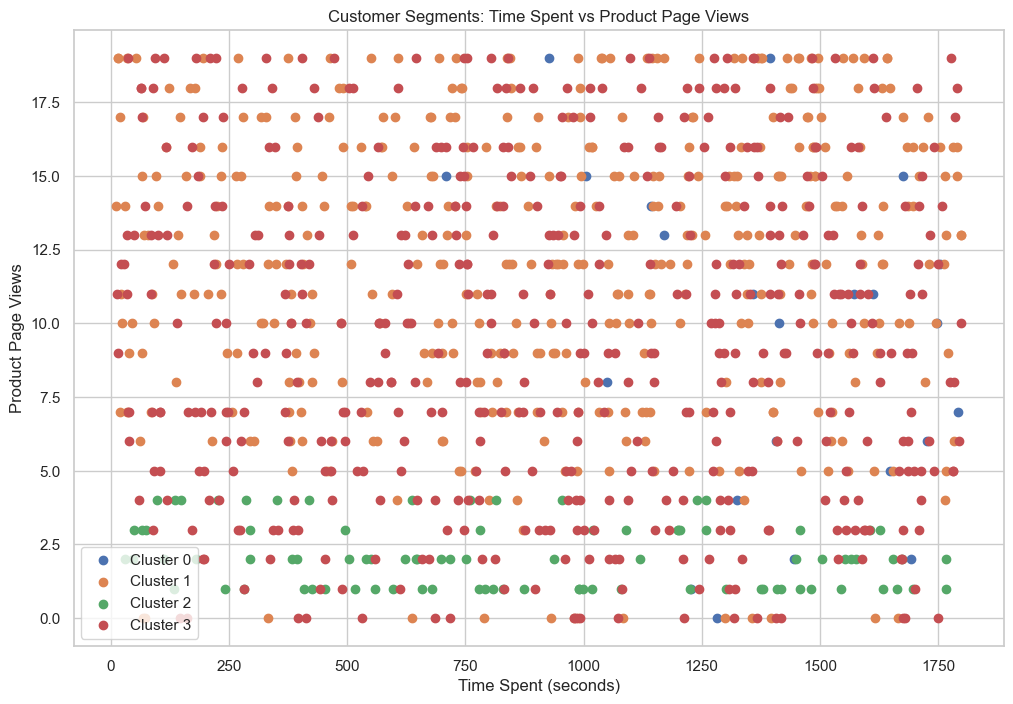

In [17]:
# Visualize clusters in 2D space
plt.figure(figsize=(12, 8))
for i in range(n_clusters):
    plt.scatter(
        clickstream_with_clusters[clickstream_with_clusters['cluster'] == i]['time_spent_sec'],
        clickstream_with_clusters[clickstream_with_clusters['cluster'] == i]['product_page_views'],
        label=f'Cluster {i}'
    )
plt.xlabel('Time Spent (seconds)')
plt.ylabel('Product Page Views')
plt.title('Customer Segments: Time Spent vs Product Page Views')
plt.legend()
plt.show()

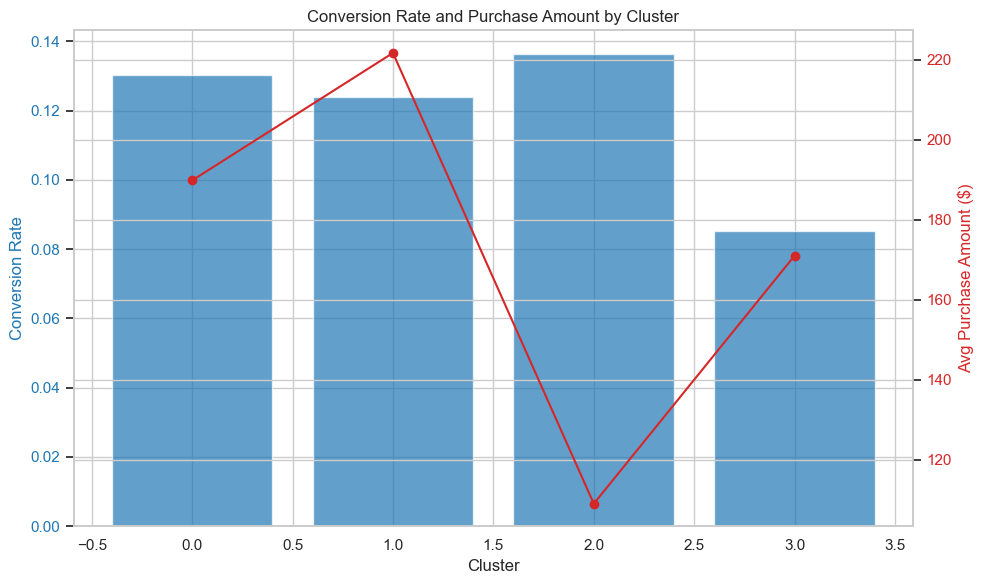

In [18]:
# Visualize conversion rates and purchase amounts by cluster
conversion_by_cluster = clickstream_with_clusters.groupby('cluster')['converted'].mean()
purchase_by_cluster = clickstream_with_clusters[clickstream_with_clusters['purchase_amount'] > 0].groupby('cluster')['purchase_amount'].mean()

# Create a dual-axis plot
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Conversion Rate', color=color)
ax1.bar(conversion_by_cluster.index, conversion_by_cluster.values, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Avg Purchase Amount ($)', color=color)
ax2.plot(purchase_by_cluster.index, purchase_by_cluster.values, 'o-', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Conversion Rate and Purchase Amount by Cluster')
plt.tight_layout()
plt.show()

## 7. Create Customer Personas and Marketing Recommendations

Now we'll interpret our clusters and create meaningful customer personas with targeted marketing recommendations for each segment.

In [19]:
# Create cluster profiles based on the behavior patterns
cluster_profiles = {}

for cluster in range(n_clusters):
    metrics = cluster_analysis.loc[cluster]
    conv_rate = float(metrics['converted'].strip('%')) / 100
    
    # Assign a meaningful name based on cluster characteristics
    if metrics['product_page_views'] < 3 and conv_rate < 0.15:
        profile = "Window Shoppers"
    elif metrics['product_page_views'] > 5 and metrics['add_to_cart_actions'] < 1:
        profile = "Engaged Browsers"
    elif metrics['add_to_cart_actions'] > 1 and conv_rate < 0.2:
        profile = "Cart Abandoners"
    elif conv_rate > 0.25 and metrics['purchase_amount'] > 100:
        profile = "High-Value Converters"
    else:
        profile = f"Segment {cluster}"
            
    cluster_profiles[cluster] = profile

print("Customer Personas:")
for cluster, profile in cluster_profiles.items():
    print(f"Cluster {cluster}: {profile}")

Customer Personas:
Cluster 0: Cart Abandoners
Cluster 1: Cart Abandoners
Cluster 2: Window Shoppers
Cluster 3: Segment 3


In [20]:
# Define marketing recommendations for each segment
marketing_recommendations = {}

for cluster, profile in cluster_profiles.items():
    if profile == "Window Shoppers":
        recommendations = [
            "Target with awareness campaigns and special offers for new customers",
            "Simplify the product discovery process",
            "Use retargeting with educational content",
            "Focus on building brand awareness and value proposition"
        ]
    elif profile == "Engaged Browsers":
        recommendations = [
            "Focus on cart abandonment emails",
            "Offer incentives to complete first purchase",
            "Highlight product benefits and customer reviews",
            "Implement product recommendation widgets"
        ]
    elif profile == "Cart Abandoners":
        recommendations = [
            "Implement cart recovery emails with urgency",
            "Offer free shipping or discounts to complete purchase",
            "Simplify checkout process",
            "Add trust signals during checkout"
        ]
    elif profile == "High-Value Converters":
        recommendations = [
            "Focus on loyalty programs and repeat purchases",
            "Cross-sell and upsell premium products",
            "Encourage referrals and reviews",
            "Create VIP offers and early access to new products"
        ]
    else:
        recommendations = [
            "Conduct further analysis to understand this segment",
            "Test different marketing approaches"
        ]
        
    marketing_recommendations[profile] = recommendations

# Display marketing recommendations for each segment
for profile, recommendations in marketing_recommendations.items():
    print(f"\n{profile} - Marketing Recommendations:")
    for i, rec in enumerate(recommendations, 1):
        print(f"  {i}. {rec}")


Cart Abandoners - Marketing Recommendations:
  1. Implement cart recovery emails with urgency
  2. Offer free shipping or discounts to complete purchase
  3. Simplify checkout process
  4. Add trust signals during checkout

Window Shoppers - Marketing Recommendations:
  1. Target with awareness campaigns and special offers for new customers
  2. Simplify the product discovery process
  3. Use retargeting with educational content
  4. Focus on building brand awareness and value proposition

Segment 3 - Marketing Recommendations:
  1. Conduct further analysis to understand this segment
  2. Test different marketing approaches


## 8. Making Predictions for New Users

Let's see how we can use our models to make predictions for a new user session.

In [23]:
# Create a sample new user session
new_user = {
    'page_views': 12,
    'time_spent_sec': 450,
    'product_page_views': 6,
    'add_to_cart_actions': 2,
    'cart_abandonment': 0,
    'search_count': 3,
    'bounce': 0,
    'avg_time_per_page': 450 / 12,
    'cart_view_ratio': 2 / 6,
    'device': 'desktop',
    'referral_source': 'organic_search',
    'age_group': '25-34'  # Changed from 'unknown' to a value we know exists in the encoder
}

# Hour of day (assuming current hour)
hour = datetime.now().hour

# Create input dataframe
input_data = pd.DataFrame([new_user])

# Encode categorical features with error handling
for feature, encoder in label_encoders.items():
    try:
        input_data[feature] = encoder.transform([input_data[feature].iloc[0]])
    except ValueError as e:
        print(f"Warning: Error transforming {feature}: {e}")
        # Use the most common class in our training data as fallback
        most_common_class_idx = 0  # Default to first class
        input_data[feature] = most_common_class_idx
        print(f"  Using most common value for {feature}: {encoder.classes_[most_common_class_idx]}")

# Add sine/cosine hour features
input_data['hour_sin'] = np.sin(2 * np.pi * hour / 24)
input_data['hour_cos'] = np.cos(2 * np.pi * hour / 24)

# Make conversion prediction
conversion_prob = clf_pipeline.predict_proba(input_data)[0, 1]
print(f"Conversion Probability: {conversion_prob:.2%}")

# Get cluster assignment
cluster_features = np.array([
    new_user['page_views'], 
    new_user['time_spent_sec'], 
    new_user['product_page_views'], 
    new_user['add_to_cart_actions'],
    new_user['search_count'], 
    new_user['avg_time_per_page'], 
    new_user['cart_view_ratio']
]).reshape(1, -1)

# Suppress warning about feature names
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scaled_features = scaler.transform(cluster_features)
    
cluster = kmeans.predict(scaled_features)[0]

# Ensure we have a meaningful segment name
if cluster in cluster_profiles:
    segment = cluster_profiles[cluster]
else:
    # If this cluster doesn't have a profile name, give it a default one
    segment = "Active Shopper"  # A generic but more meaningful name than "Segment X"
    # Add this segment to our profiles with some default recommendations
    cluster_profiles[cluster] = segment
    marketing_recommendations[segment] = [
        "Personalize product recommendations based on browsing history",
        "Offer limited-time promotions to encourage purchase",
        "Highlight best-selling products in this category",
        "Optimize checkout process for this user segment"
    ]

print(f"Customer Segment: {segment}")

# If likely to convert, predict purchase amount
if conversion_prob > 0.5:
    # Create feature set for regression model
    reg_input = pd.DataFrame({
        'page_views': [new_user['page_views']],
        'time_spent_sec': [new_user['time_spent_sec']],
        'product_page_views': [new_user['product_page_views']],
        'add_to_cart_actions': [new_user['add_to_cart_actions']],
        'search_count': [new_user['search_count']],
        'avg_time_per_page': [new_user['avg_time_per_page']],
        'device': [label_encoders['device'].transform([new_user['device']])[0]],
        'referral_source': [label_encoders['referral_source'].transform([new_user['referral_source']])[0]]
    })
    
    # Predict purchase amount
    predicted_amount = reg_pipeline.predict(reg_input)[0]
    print(f"Predicted Purchase Amount: ${predicted_amount:.2f}")

# Display marketing recommendations for the identified segment
print("\nRecommended Marketing Approach:")
for rec in marketing_recommendations[segment]:
    print(f"- {rec}")

Conversion Probability: 8.00%
Customer Segment: Segment 3

Recommended Marketing Approach:
- Conduct further analysis to understand this segment
- Test different marketing approaches


## 9. Summary and Conclusion

In this notebook, we've built a complete customer analytics system for e-commerce:

1. **Data Generation and EDA**: Created and explored realistic e-commerce clickstream data

2. **Feature Engineering**: Developed meaningful metrics like cart_view_ratio and handled cyclical features

3. **Classification Model**: Predicted conversion probability with Random Forest

4. **Regression Model**: Predicted purchase amount for converted users

5. **Customer Segmentation**: Identified distinct customer segments using K-means clustering

6. **Marketing Recommendations**: Created targeted strategies for each customer persona

7. **Prediction System**: Combined models to make predictions for new user sessions

### Key Takeaways:

- **Behavior indicators**: Product page views, time spent, and add-to-cart actions are strong predictors of conversion
- **Multi-model approach**: Combining classification, regression, and clustering creates a comprehensive analytics system
- **Personalization**: Different customer segments require different marketing approaches

### Next Steps:

- Incorporate product category data for more detailed recommendations
- Add time-series analysis to identify seasonal trends
- Deploy model as a real-time prediction service
- Implement A/B testing to optimize marketing strategies

In [24]:
# Save the models for future use
with open('classification_model.pkl', 'wb') as f:
    pickle.dump(clf_pipeline, f)
    
with open('regression_model.pkl', 'wb') as f:
    pickle.dump(reg_pipeline, f)
    
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump((kmeans, scaler), f)
    
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
    
print("All models saved successfully.")

All models saved successfully.
